In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.- Analis exploratorio

In [2]:
df = pd.read_csv('/home/davian/Projects/ML-DL-LAB/ml/regression/data/raw/BostonHousing.csv')

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.shape

(506, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [8]:
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isin([np.inf, -np.inf]).sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [11]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [12]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [13]:
df_num = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat', 'medv']

In [14]:
df_cat = ['chas', 'rad']

In [15]:
df_ent = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax','ptratio', 'b', 'lstat', 'medv']

In [25]:
df_sin_medv = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']

### A.- Analisis univariado

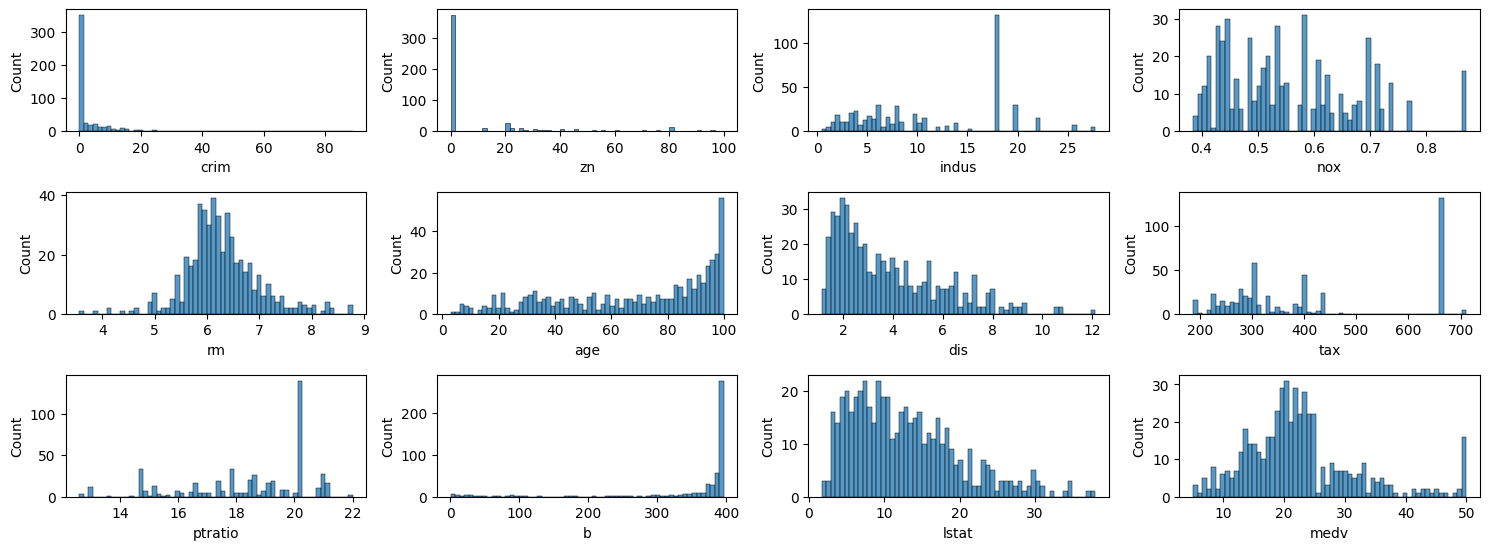

In [17]:
plt.figure(figsize=(15, 7))

for i, columna in enumerate(df_num, start=1):
    plt.subplot(4, 4, i)
    sns.histplot(data=df, x=columna, bins=60)
    plt.tight_layout()

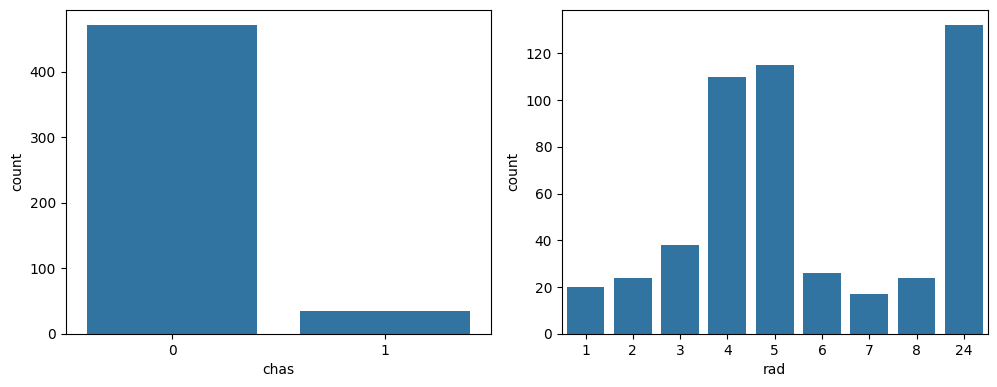

In [18]:
plt.figure(figsize=(20, 15))

for i, columna in enumerate(df_cat, start=1):
    plt.subplot(4, 4, i)
    sns.countplot(data=df, x=columna)
    plt.tight_layout()

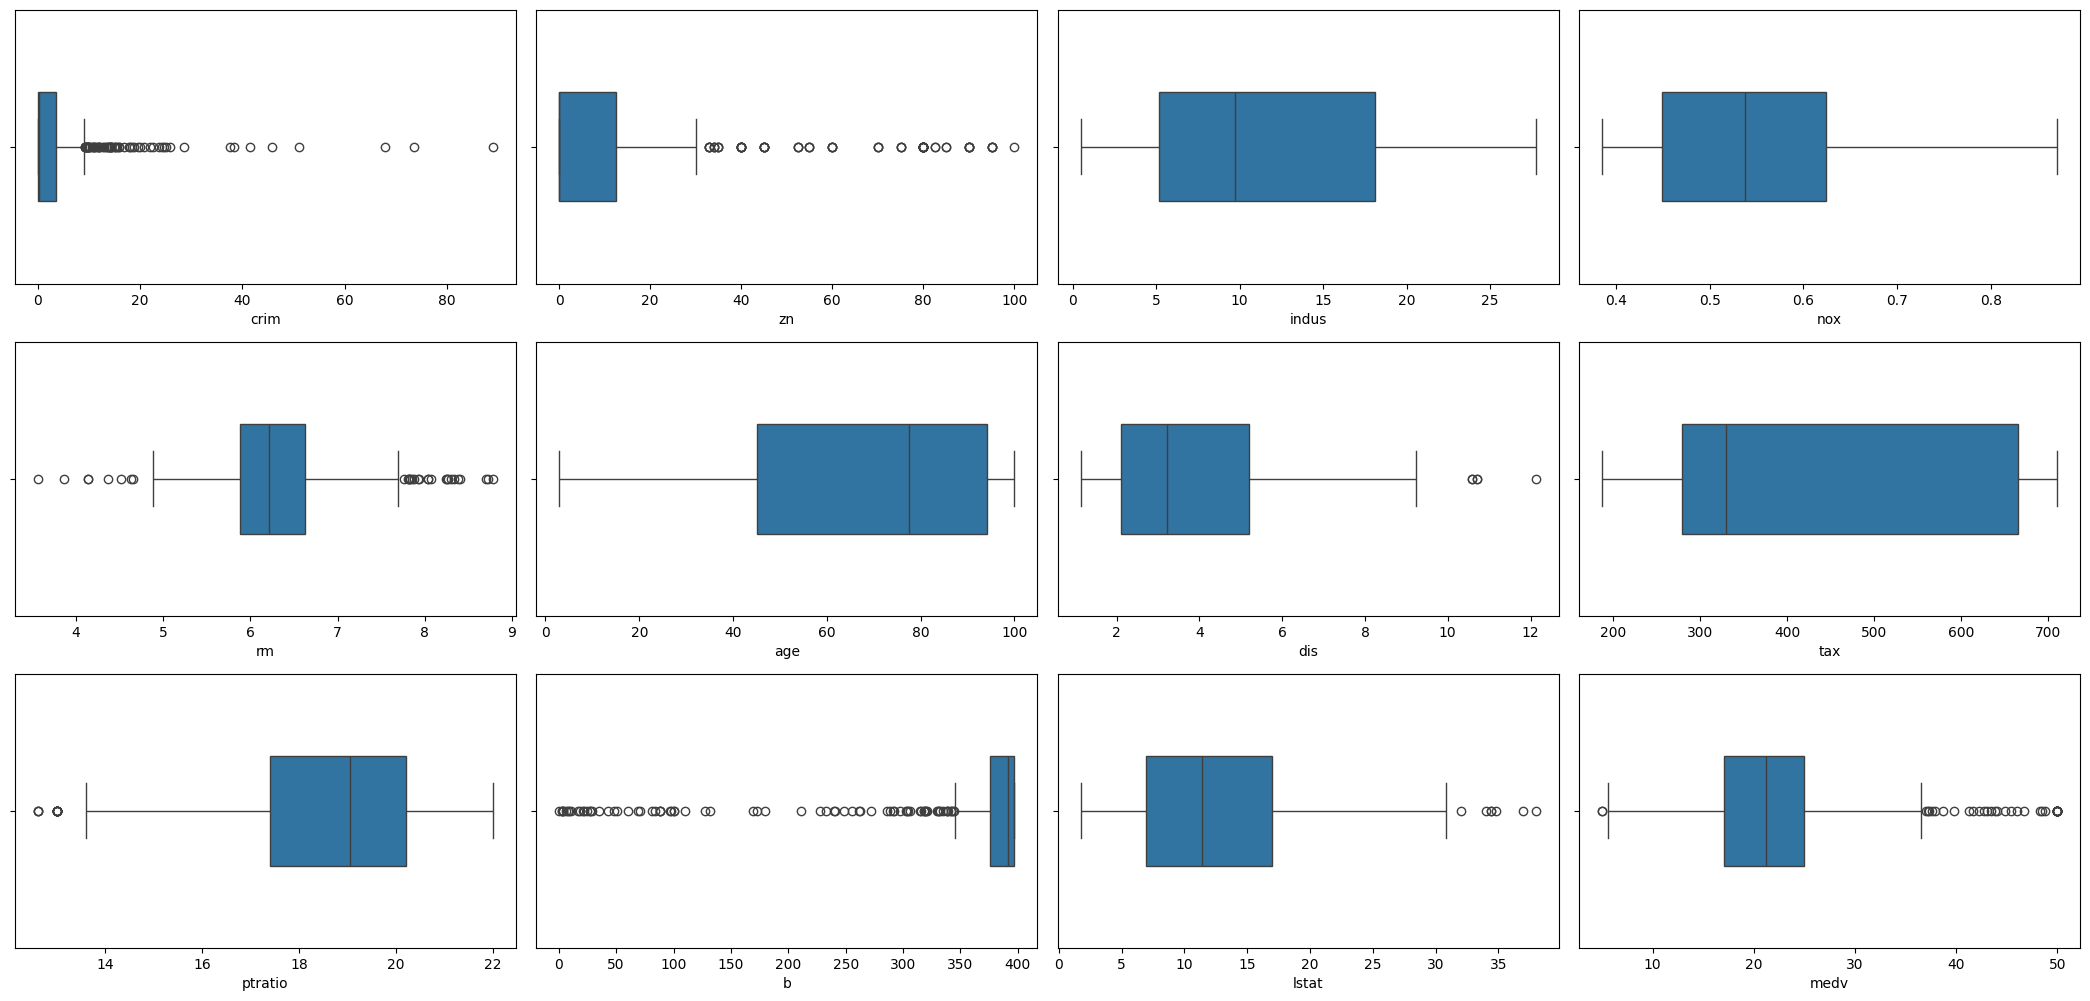

In [19]:
plt.figure(figsize=(21, 13))

for i, columna in enumerate(df_num, start=1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=df, x=columna, width=0.4)
    plt.tight_layout()

### B.- Analisis bivariado

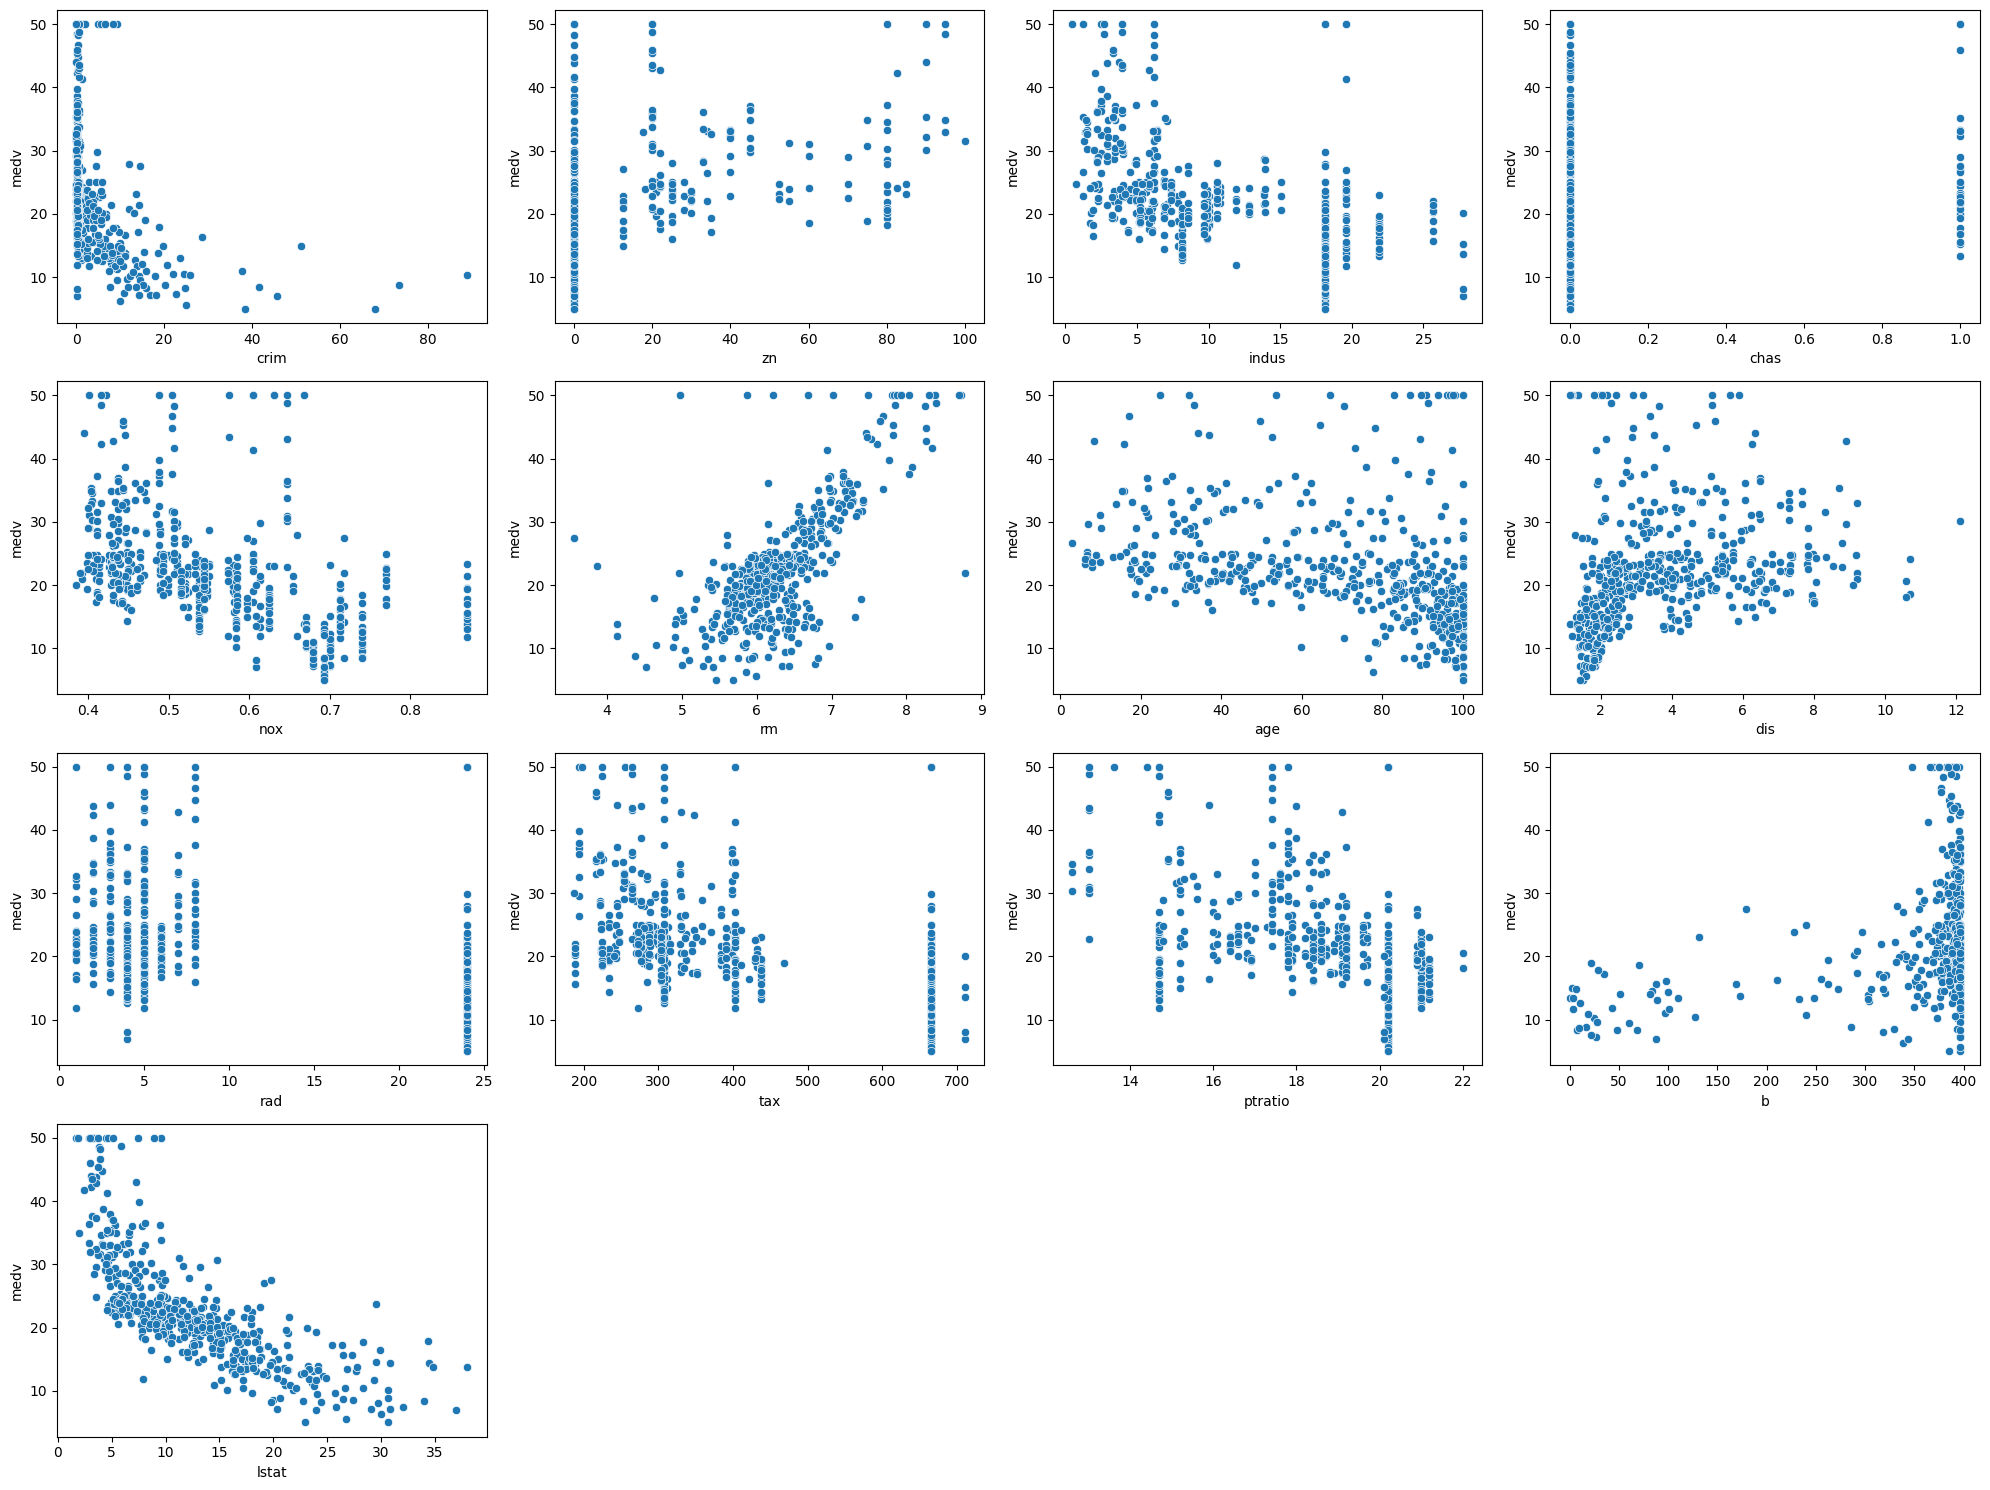

In [27]:
plt.figure(figsize=(20, 15))

for i, columna in enumerate(df_sin_medv, start=1):
    plt.subplot(4, 4, i)
    sns.scatterplot(data=df, x=columna, y='medv')
    plt.tight_layout()

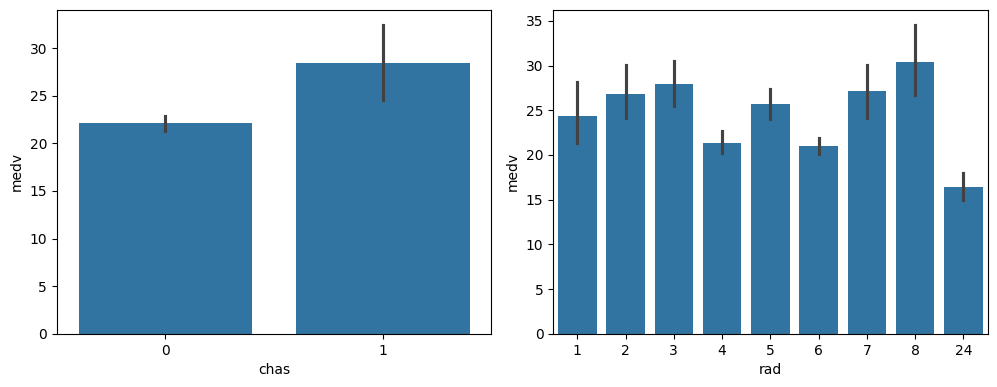

In [28]:
plt.figure(figsize=(20, 15))

for i, columna in enumerate(df_cat, start=1):
    plt.subplot(4, 4, i)
    sns.barplot(data=df, x=columna, y='medv')
    plt.tight_layout()

<Axes: >

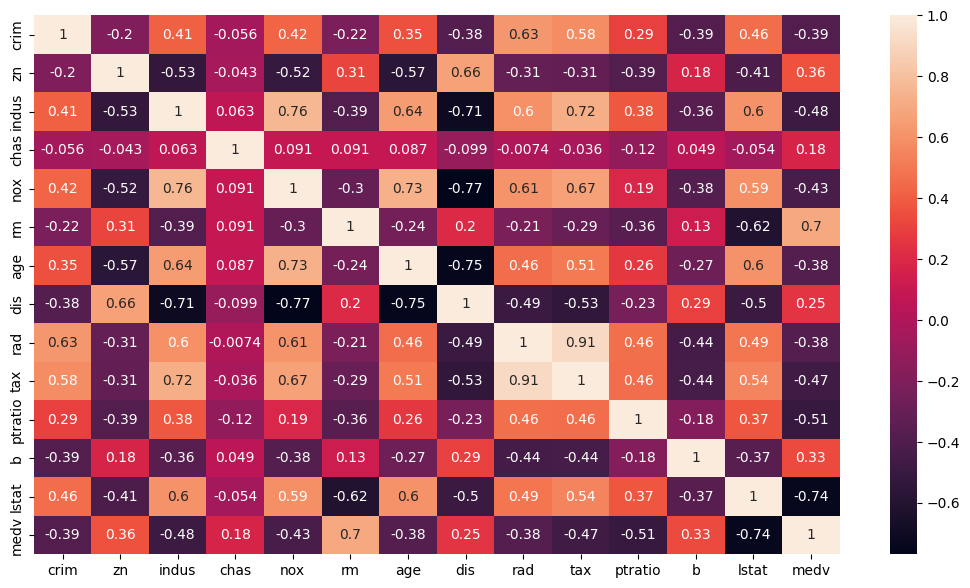

In [29]:
plt.figure(figsize=(13, 7))
sns.heatmap(data=df.corr(), annot=True)

### C.- Conclusion

**Variables con mayor correlación lineal con `medv`:**
- **`rm`** — relación positiva fuerte (más habitaciones → mayor precio).
- **`lstat`** — relación negativa fuerte (más población baja recursos → menor precio).
- **`dis`** — relación positiva moderada.
- **`crim`**, **`nox`**, **`age`**, **`indus`**, **`tax`**, **`ptratio`** — relaciones negativas débiles a moderadas.
- **`zn`**, **`b`** — sin relación lineal clara.
- **`chas`** — las casas cerca del río Charles tienen precios ligeramente más altos.

**A considerar para modelado:**
- Varias columnas presentan valores atípicos y distribuciones sesgadas (`crim`, `zn`, `b`, `chas`), lo que podría requerir transformaciones (log, Box-Cox).
- No hay predictores con colinealidad extrema, aunque `tax` y `rad` están altamente correlacionados entre sí.

### Preprocesamiento recomendado

1. **Estandarizar** — todas las features numéricas con `StandardScaler`.
2. **Transformar target** — `medv` tiene sesgo, probar log.
3. **Train-test split** — 80/20.